In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_csv('ai_job_dataset.csv')
print(f"Dataset loaded successfully Shape: {df.shape}")
display(df.head())

Dataset loaded successfully Shape: (15000, 19)


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [3]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

Duplicates removed: 0


In [4]:
print(df.isnull().sum())

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64


In [5]:
num_cols_all = df.select_dtypes(include=[np.number]).columns
cat_cols_all = df.select_dtypes(include=["object"]).columns
for c in num_cols_all:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols_all:
    df[c] = df[c].fillna(df[c].mode()[0])

In [6]:
df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")
df["application_deadline"] = pd.to_datetime(df["application_deadline"], errors="coerce")

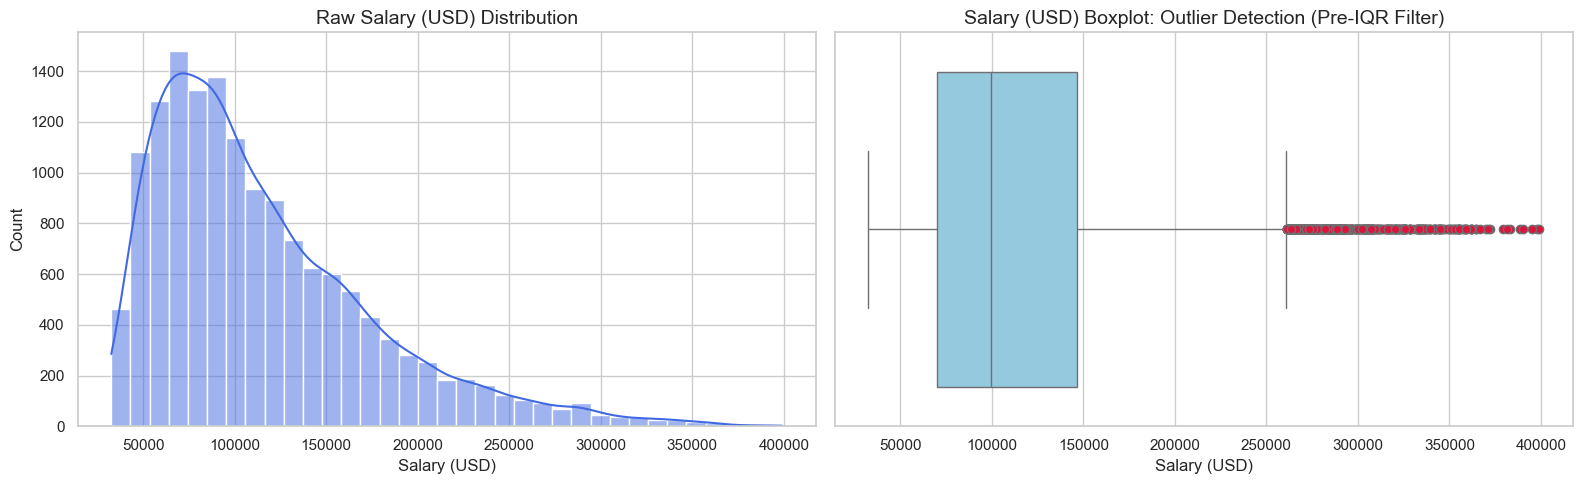

In [7]:

# VISUALIZATION BEFORE MODELING: Outlier & Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of Raw Salary
sns.histplot(df["salary_usd"], kde=True, color="royalblue", bins=35, ax=axes[0])
axes[0].set_title("Raw Salary (USD) Distribution", fontsize=14)
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Count")

# Boxplot to highlight extreme outliers
sns.boxplot(x=df["salary_usd"], color="skyblue", flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6), ax=axes[1])
axes[1].set_title("Salary (USD) Boxplot: Outlier Detection (Pre-IQR Filter)", fontsize=14)
axes[1].set_xlabel("Salary (USD)")

plt.tight_layout()
plt.show()

In [8]:
q1, q3 = df["salary_usd"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
before = len(df)
df = df[(df["salary_usd"] >= lower) & (df["salary_usd"] <= upper)]
print(f"\nOutlier rows removed (IQR rule on salary_usd): {before - len(df)}")
print(f"Salary range kept: ${lower:,.0f} - ${upper:,.0f}")


Outlier rows removed (IQR rule on salary_usd): 483
Salary range kept: $-44,163 - $260,752


In [9]:
#df["num_skills"] = df["required_skills"].apply(lambda s: len(str(s).split(",")))
from sklearn.preprocessing import MultiLabelBinarizer

# Convert skills into a list
df["skill_list"] = df["required_skills"].apply(
    lambda x: [skill.strip() for skill in str(x).split(",")]
)

# Multi-label binary encoding
mlb = MultiLabelBinarizer()

skill_encoded = mlb.fit_transform(df["skill_list"])

skill_df = pd.DataFrame(
    skill_encoded,
    columns=[f"skill_{skill}" for skill in mlb.classes_],
    index=df.index
)

# Add encoded skill columns
df = pd.concat([df, skill_df], axis=1)

# Remove original skills column
df = df.drop(columns=["required_skills", "skill_list"])

In [10]:
df["days_open"] = (df["application_deadline"] - df["posting_date"]).dt.days
df["days_open"] = df["days_open"].fillna(df["days_open"].median())

In [12]:
drop_cols = ["job_id", "company_name",
             "posting_date", "application_deadline", "salary_currency"]
df_model = df.drop(columns=drop_cols)

In [13]:
print("Engineered features added: num_skills, days_open")
print(f"Final feature set ({df_model.shape[1]-1} features + 1 target):")
print(list(df_model.columns))

Engineered features added: num_skills, days_open
Final feature set (37 features + 1 target):
['job_title', 'salary_usd', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'job_description_length', 'benefits_score', 'skill_AWS', 'skill_Azure', 'skill_Computer Vision', 'skill_Data Visualization', 'skill_Deep Learning', 'skill_Docker', 'skill_GCP', 'skill_Git', 'skill_Hadoop', 'skill_Java', 'skill_Kubernetes', 'skill_Linux', 'skill_MLOps', 'skill_Mathematics', 'skill_NLP', 'skill_PyTorch', 'skill_Python', 'skill_R', 'skill_SQL', 'skill_Scala', 'skill_Spark', 'skill_Statistics', 'skill_Tableau', 'skill_TensorFlow', 'days_open']


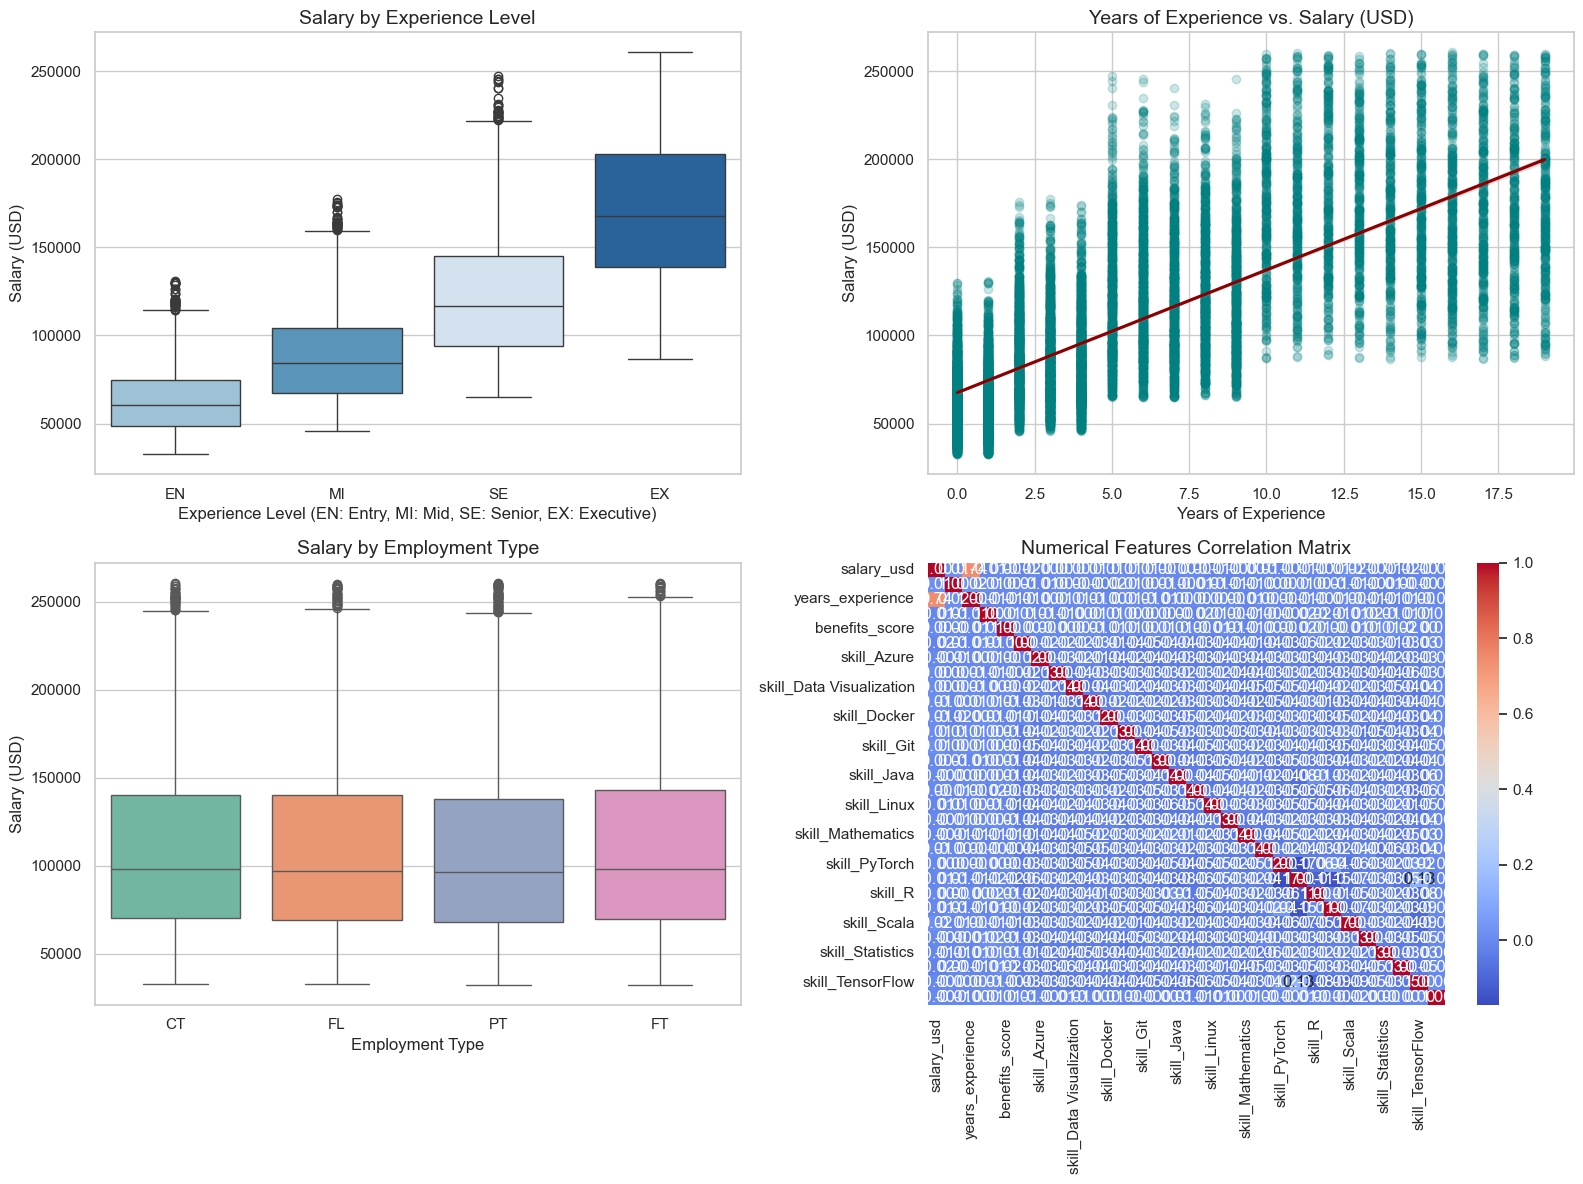

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as s
# VISUALIZATION BEFORE MODELING: Feature Relationships with Salary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Experience Level vs Salary
exp_order = ["EN", "MI", "SE", "EX"]
valid_exp_order = [e for e in exp_order if e in df_model["experience_level"].unique()]
sns.boxplot(
    x="experience_level", 
    y="salary_usd", 
    hue="experience_level", 
    data=df_model, 
    order=valid_exp_order, 
    palette="Blues", 
    legend=False, 
    ax=axes[0, 0]
)
axes[0, 0].set_title("Salary by Experience Level", fontsize=14)
axes[0, 0].set_xlabel("Experience Level (EN: Entry, MI: Mid, SE: Senior, EX: Executive)")
axes[0, 0].set_ylabel("Salary (USD)")

# 2. Years of Experience vs Salary
sns.regplot(
    x="years_experience", 
    y="salary_usd", 
    data=df_model, 
    scatter_kws={"alpha": 0.2, "color": "teal"}, 
    line_kws={"color": "darkred"}, 
    ax=axes[0, 1]
)
axes[0, 1].set_title("Years of Experience vs. Salary (USD)", fontsize=14)
axes[0, 1].set_xlabel("Years of Experience")
axes[0, 1].set_ylabel("Salary (USD)")

# 3. Employment Type vs Salary
sns.boxplot(
    x="employment_type", 
    y="salary_usd", 
    hue="employment_type", 
    data=df_model, 
    palette="Set2", 
    legend=False, 
    ax=axes[1, 0]
)
axes[1, 0].set_title("Salary by Employment Type", fontsize=14)
axes[1, 0].set_xlabel("Employment Type")
axes[1, 0].set_ylabel("Salary (USD)")

# 4. Correlation Heatmap of Numerical Features
num_cols = df_model.select_dtypes(include=[np.number]).columns
corr = df_model[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True, ax=axes[1, 1])
axes[1, 1].set_title("Numerical Features Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [16]:
TARGET = "salary_usd"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

In [17]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")

Categorical features (8): ['job_title', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'education_required', 'industry']
Numeric features (29): ['remote_ratio', 'years_experience', 'job_description_length', 'benefits_score', 'skill_AWS', 'skill_Azure', 'skill_Computer Vision', 'skill_Data Visualization', 'skill_Deep Learning', 'skill_Docker', 'skill_GCP', 'skill_Git', 'skill_Hadoop', 'skill_Java', 'skill_Kubernetes', 'skill_Linux', 'skill_MLOps', 'skill_Mathematics', 'skill_NLP', 'skill_PyTorch', 'skill_Python', 'skill_R', 'skill_SQL', 'skill_Scala', 'skill_Spark', 'skill_Statistics', 'skill_Tableau', 'skill_TensorFlow', 'days_open']

Train rows: 11,613  |  Test rows: 2,904


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [19]:
models = {
    "Linear Regression":        LinearRegression(),
    "Ridge Regression (L2)":    Ridge(alpha=10.0, random_state=42),
    "Lasso Regression (L1)":    Lasso(alpha=100.0, random_state=42, max_iter=10000),
    "ElasticNet (L1+L2)":       ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000),
    "Decision Tree":            DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest":            RandomForestRegressor(n_estimators=300, max_depth=12,
                                                        random_state=42, n_jobs=-1),
   "Gradient Boosting":        GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                                            learning_rate=0.05, random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    # 5-fold cross-validation R2 for a more robust performance estimate
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1).mean()

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_mean": cv_r2,
    })
    fitted_pipelines[name] = pipe
    print(f"{name:28s} | RMSE: {rmse:9,.0f} | R2: {r2:6.4f} | CV R2: {cv_r2:6.4f}")

Linear Regression            | RMSE:    18,591 | R2: 0.8649 | CV R2: 0.8639
Ridge Regression (L2)        | RMSE:    18,595 | R2: 0.8648 | CV R2: 0.8636
Lasso Regression (L1)        | RMSE:    18,659 | R2: 0.8639 | CV R2: 0.8629
ElasticNet (L1+L2)           | RMSE:    22,863 | R2: 0.7956 | CV R2: 0.7932
Decision Tree                | RMSE:    23,626 | R2: 0.7818 | CV R2: 0.7757
Random Forest                | RMSE:    18,647 | R2: 0.8641 | CV R2: 0.8596
Gradient Boosting            | RMSE:    17,274 | R2: 0.8833 | CV R2: 0.8815


In [20]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df.to_csv("model_comparison_results.csv", index=False)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"\nBest model by R2: {best_model_name}")

                Model          MAE          MSE         RMSE       R2  CV_R2_mean
    Gradient Boosting 12972.532825 2.983849e+08 17273.820906 0.883350    0.881467
    Linear Regression 14232.225386 3.456190e+08 18590.830590 0.864884    0.863879
Ridge Regression (L2) 14187.633104 3.457719e+08 18594.942197 0.864824    0.863571
        Random Forest 14195.569775 3.477151e+08 18647.119359 0.864065    0.859606
Lasso Regression (L1) 14058.129074 3.481432e+08 18658.594871 0.863897    0.862901
   ElasticNet (L1+L2) 16671.909558 5.227237e+08 22863.152584 0.795647    0.793178
        Decision Tree 18023.500304 5.582112e+08 23626.493340 0.781773    0.775701

Best model by R2: Gradient Boosting


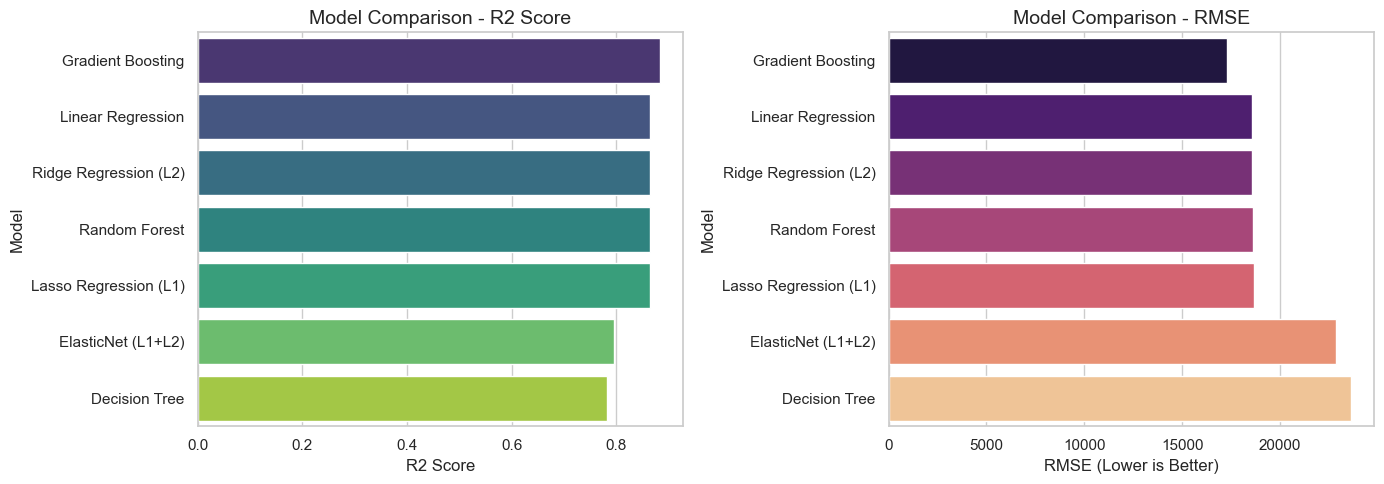

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns


# VISUALIZATION AFTER MODELING: Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. R2 Score Comparison
sns.barplot(
    x="R2", 
    y="Model", 
    hue="Model", 
    data=results_df, 
    palette="viridis", 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title("Model Comparison - R2 Score", fontsize=14)
axes[0].set_xlabel("R2 Score")
axes[0].set_ylabel("Model")

# 2. RMSE Comparison
sns.barplot(
    x="RMSE", 
    y="Model", 
    hue="Model", 
    data=results_df, 
    palette="magma", 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title("Model Comparison - RMSE", fontsize=14)
axes[1].set_xlabel("RMSE (Lower is Better)")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()

In [22]:
joblib.dump(best_pipeline, "best_salary_model.pkl")
print("Saved: best_salary_model.pkl")


Saved: best_salary_model.pkl
